# 02 驱动因素分析：哪些特征与转化相关，分旅程阶段是否不同？

## 业务问题

1. 哪些特征和"是否办理定存"**相关**（关联强度）？最强的特征是什么？
2. 这种关联在**首次触达（first_time）**和**回归客（returning）**两个旅程阶段里是否不同？
3. 关联强度排前三的特征，两个阶段是否一致？——如果驱动因素因阶段而异，"一刀切"的外呼策略就会失效。

> 口径警示：本 notebook 度量的是**关联（association）**，不是因果。"驱动因素"在本文中特指"与转化相关性最强的特征"，关联 ≠ 因果（因果方向与选择偏差问题由 00 文档声明三/四约束，渠道的因果问题在 notebook 04 用 PSM 正式处理）。

## 口径与方法假设定义

### 特征集（沿用 00 文档声明一：duration 数据泄漏）

- **`duration` 明确排除**：通话时长是结果不是原因，任何"外呼前"分析不得使用。本 notebook 的特征集为：
  - 人口统计：`age`、`job`、`marital`、`education`、`default`、`housing`、`loan`
  - 联系信息：`contact`、`month`、`day_of_week`、`campaign`
  - 历史痕迹：`previous`、`pdays`、`poutcome`
  - 社会经济背景（宏观）：`emp.var.rate`、`cons.price.idx`、`cons.conf.idx`、`euribor3m`、`nr.employed`
- 特征集中**不含 `duration`**，代码里以特征列表显式声明并在结果中复核。

### 关联度量方法：卡方检验 + Cramér's V

- 所有特征统一转换为**类别**后做 `scipy.stats.chi2_contingency`（卡方独立性检验），再用 **Cramér's V** 度量关联强度：
  `V = sqrt(χ² / (n × min(r−1, c−1)))`，取值范围 0（无关联）~ 1（完全关联），不受样本量影响，可在特征间横向比较。
- 连续变量（`age` 及宏观变量）统一 **分位数分桶（qcut 5 桶，允许去重）** 后进入；计数型变量（`campaign`、`previous`）直接作为类别。
- 组内**无变异的变量**（如 first_time 组中 `previous`/`pdays`/`poutcome` 全部为常数）无法做卡方检验，显式标注"组内无变异，跳过"——这本身是发现。

### 旅程分组口径（与 notebook 01 一致）

- `previous > 0` 判定 returning（回归客），`previous == 0` 判定 first_time（首次触达）——不单独用 `pdays != 999`（见 01 的 pdays 哨兵值发现与 00 文档 §2.3）。

### campaign 的定位（沿用 00 文档声明四）

- `campaign` 与转化相关是可呈现的**关联事实**，但存在**反向因果（confounding by indication）**——打更多电话是"销售判断客户有希望"的结果，销售主观判断不可观测。因此本 notebook 中 campaign 的关联值**不能解读为"驱动因素"**（因果方向未定），仅作描述性呈现，任何因果声称都被禁止；完整的描述性边际分析在 notebook 05。

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# 定位项目根目录并加入模块搜索路径（与 notebook 01 相同的启动逻辑）
_CWD = Path.cwd()
_PROBE = Path("src") / "telemarketing_utils.py"
if not (_CWD / _PROBE).exists() and (_CWD.parent / _PROBE).exists():
    sys.path.insert(0, str(_CWD.parent))
else:
    sys.path.insert(0, str(_CWD))

from src.telemarketing_utils import find_project_root, setup_plot_style  # noqa: E402

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "bank-additional-full.csv"
REPORT_DIR = PROJECT_ROOT / "reports"

setup_plot_style()
import matplotlib.pyplot as plt  # noqa: E402

df = pd.read_csv(DATA_PATH, sep=";")
df["journey"] = np.where(df["previous"] == 0, "first_time", "returning")
# pdays 分桶（与 notebook 01 口径一致：=0天 / 1-3 / 4-7 / 8-14 / 15-27 / 999）
df["pdays_bucket"] = pd.cut(
    df["pdays"], bins=[-1, 0, 3, 7, 14, 27, 999],
    labels=["=0天", "1-3天", "4-7天", "8-14天", "15-27天", "999（从未/不可考）"],
)
print("总样本:", len(df), "| first_time:", int((df["journey"] == "first_time").sum()),
      "| returning:", int((df["journey"] == "returning").sum()))

总样本: 41188 | first_time: 35563 | returning: 5625


In [2]:
# duration 排除确认：特征集显式不含 duration
EXCLUDED = ["duration"]
FEATURES = [c for c in df.columns if c not in ["y", "journey", "duration"]]
print("特征集字段数:", len(FEATURES), "（不含 duration）")
assert "duration" not in FEATURES, "duration 必须被排除"
print("duration 已确认排除:", "duration" in EXCLUDED)
print()
print("特征集:", ", ".join(FEATURES))

特征集字段数: 20 （不含 duration）
duration 已确认排除: True

特征集: age, job, marital, education, default, housing, loan, contact, month, day_of_week, campaign, pdays, previous, poutcome, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed, pdays_bucket


In [3]:
def cramers_v(a: pd.Series, b: pd.Series) -> tuple[float, float]:
    """卡方独立性检验 + Cramér's V 关联强度。返回 (V, p值)。"""
    ct = pd.crosstab(a, b)
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan, np.nan
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    v = np.sqrt(chi2 / (n * min(ct.shape[0] - 1, ct.shape[1] - 1)))
    return v, p


# 分类变量（含计数型）；连续变量统一 qcut 5 分位后进入
CATEGORICAL = ["job", "marital", "education", "default", "housing", "loan",
               "contact", "month", "day_of_week", "campaign",
               "previous", "pdays_bucket", "poutcome"]
CONTINUOUS = ["age", "emp.var.rate", "cons.price.idx", "cons.conf.idx",
              "euribor3m", "nr.employed"]


def journey_driver_table(sub: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for v in CATEGORICAL:
        if sub[v].nunique() < 2:
            rows.append({"特征": v, "Cramér's V": np.nan, "p值": np.nan, "备注": "组内无变异，跳过"})
            continue
        vv, p = cramers_v(sub[v], sub["y"])
        rows.append({"特征": v, "Cramér's V": round(vv, 4), "p值": p, "备注": ""})
    for v in CONTINUOUS:
        try:
            binned = pd.qcut(sub[v], q=5, duplicates="drop").astype(str)
        except ValueError:
            rows.append({"特征": v, "Cramér's V": np.nan, "p值": np.nan, "备注": "组内无变异，跳过"})
            continue
        vv, p = cramers_v(binned, sub["y"])
        rows.append({"特征": v, "Cramér's V": round(vv, 4), "p值": p, "备注": ""})
    return pd.DataFrame(rows).sort_values("Cramér's V", ascending=False, na_position="last")


def annotate_signif(tab: pd.DataFrame) -> pd.DataFrame:
    out = tab.copy()
    out["显著性"] = np.where(out["p值"].isna(), "—",
                      np.where(out["p值"] < 0.05, "显著", "不显著"))
    return out


tab_first = annotate_signif(journey_driver_table(df[df["journey"] == "first_time"]))
tab_return = annotate_signif(journey_driver_table(df[df["journey"] == "returning"]))
print("first_time 组（n=35,563，转化率 8.83%）关联强度排名:")
display(tab_first)
print()
print("returning 组（n=5,625，转化率 26.65%）关联强度排名:")
display(tab_return)

first_time 组（n=35,563，转化率 8.83%）关联强度排名:


,特征,Cramér's V,p值,备注,显著性
18,nr.employed,0.2497,0.000000e+00,,显著
7,month,0.2446,0.000000e+00,,显著
17,euribor3m,0.2188,0.000000e+00,,显著
14,emp.var.rate,0.2102,0.000000e+00,,显著
15,cons.price.idx,0.1944,7.093158e-290,,显著
6,contact,0.1219,5.063082e-117,,显著
0,job,0.1163,3.703082e-96,,显著
16,cons.conf.idx,0.0818,3.027571e-51,,显著
3,default,0.0772,8.877941e-47,,显著
13,age,0.0694,5.053058e-36,,显著



returning 组（n=5,625，转化率 26.65%）关联强度排名:


,特征,Cramér's V,p值,备注,显著性
11,pdays_bucket,0.5123,0.000000e+00,,显著
12,poutcome,0.4939,2.372921e-300,,显著
18,nr.employed,0.4898,2.953359e-292,,显著
16,cons.conf.idx,0.4622,2.819190e-260,,显著
17,euribor3m,0.4584,1.227330e-254,,显著
7,month,0.3947,8.543233e-183,,显著
15,cons.price.idx,0.3356,5.211266e-137,,显著
10,previous,0.2624,1.574084e-80,,显著
0,job,0.2341,1.620067e-59,,显著
14,emp.var.rate,0.2309,8.015168e-66,,显著


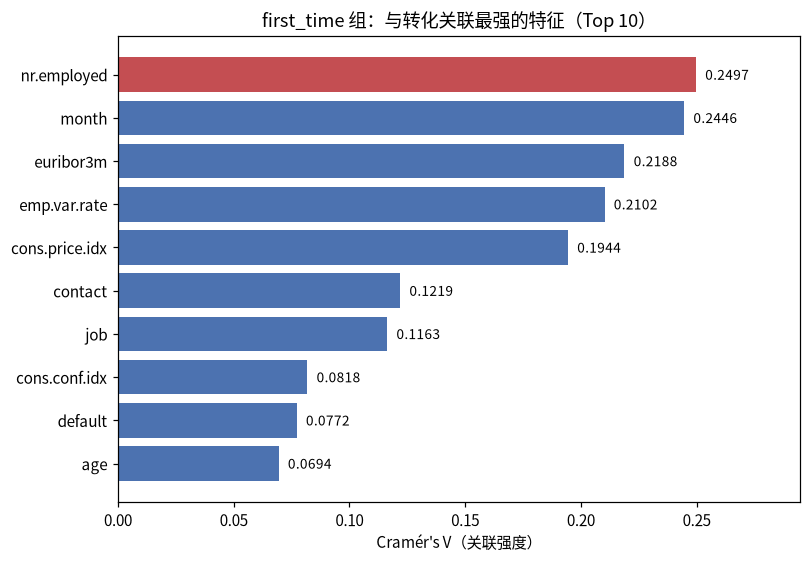

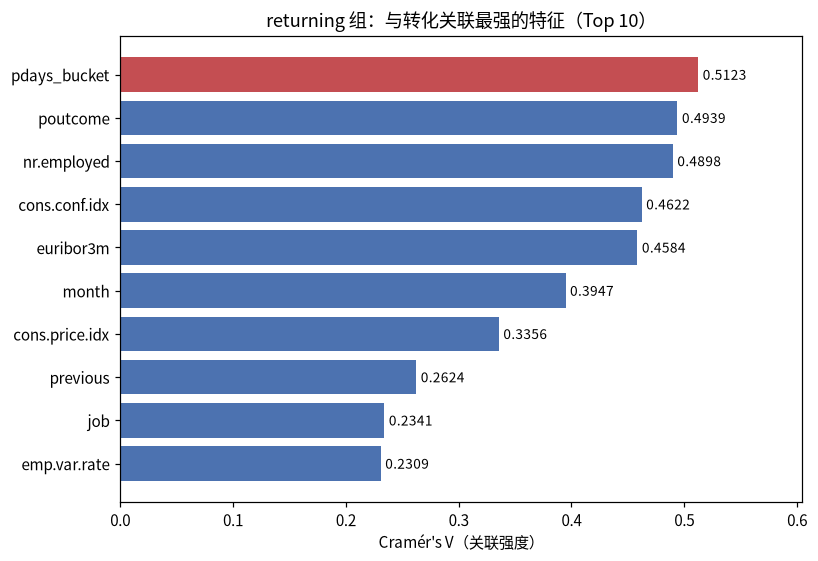

In [4]:
def plot_top_drivers(tab: pd.DataFrame, title: str, fname: str, top: int = 10):
    plot_tab = tab.dropna(subset=["Cramér's V"]).head(top)
    plot_tab = plot_tab.iloc[::-1]  # 最高在上
    fig, ax = plt.subplots(figsize=(8, 5.5))
    colors = ["#C44E52" if i == len(plot_tab) - 1 else "#4C72B0" for i in range(len(plot_tab))]
    bars = ax.barh(plot_tab["特征"], plot_tab["Cramér's V"], color=colors)
    for bar, v in zip(bars, plot_tab["Cramér's V"]):
        ax.text(bar.get_width() + 0.004, bar.get_y() + bar.get_height() / 2,
                f"{v:.4f}", va="center", fontsize=9)
    ax.set_xlabel("Cramér's V（关联强度）")
    ax.set_title(title)
    ax.set_xlim(0, plot_tab["Cramér's V"].max() * 1.18)
    plt.savefig(REPORT_DIR / fname, bbox_inches="tight")
    plt.show()


plot_top_drivers(tab_first, "first_time 组：与转化关联最强的特征（Top 10）", "02_drivers_first_time.png")
plot_top_drivers(tab_return, "returning 组：与转化关联最强的特征（Top 10）", "02_drivers_returning.png")

In [5]:
# 预演 notebook 04：contact（渠道）在两组中的转化率与关联强度
for grp in ["first_time", "returning"]:
    sub = df[df["journey"] == grp]
    ct = sub["y"].eq("yes").groupby(sub["contact"]).agg(记录数="count", 转化率="mean")
    vv, p = cramers_v(sub["contact"], sub["y"])
    print(f"[{grp}] contact 转化率：")
    print(ct.round(4))
    print(f"  → Cramér's V = {vv:.4f}, p = {p:.4g}")
    print()

[first_time] contact 转化率：
             记录数     转化率
contact                 
cellular   20922  0.1173
telephone  14641  0.0469
  → Cramér's V = 0.1219, p = 5.063e-117

[returning] contact 转化率：
            记录数     转化率
contact                
cellular   5222  0.2679
telephone   403  0.2481
  → Cramér's V = 0.0108, p = 0.4201



## 业务解读与决策建议

**核心结论：两个旅程阶段的"驱动因素"完全不同——新客由市场时机主导，回归客由历史状态主导。**

### first_time 组（新客，n=35,563，转化率 8.83%）排名前三

1. `nr.employed`（就业人数，宏观，0.2497）
2. `month`（月份，0.2446）
3. `euribor3m`（欧元同业拆借利率，宏观，0.2188）

新客的转化主要由**市场环境与活动时点**驱动（月转化率从 6.4%（may）到 50.5%（mar）不等——数据采集期恰逢金融危机，市场波动剧烈）；`contact` 渠道仅排第 6（0.1219），`job` 第 7（0.1163）。

### returning 组（回归客，n=5,625，转化率 26.65%）排名前三

1. `pdays_bucket`（距上次联系天数分桶，0.5123）
2. `poutcome`（上次活动结果，0.4939）
3. `nr.employed`（宏观，0.4898）

回归客的转化主要由**历史状态**主导——"上次联系距今多久"和"上次结果如何"几乎决定了回归客的转化水平（呼应 01：窗口内 63.8% vs 窗口外 12.9%）。注意 `pdays_bucket` 与 `poutcome` 高度共线（success 全部落在窗口内），两者信息重叠；宏观变量在两组中都很强，但 returning 组的记录时间高度集中，宏观关联部分反映的是采集期混叠。

### 一致性判断

- **两组前三不一致**：first_time 是"时机三件套"（宏观+月份），returning 是"历史三件套"（再触达窗口+上次结果+宏观）。对"一刀切"策略的直接启示：**新客和回归客必须用不同的优先级逻辑**（对应 01 的资源分层建议）。
- **contact 的跨组反差**（预演 04）：first_time 组渠道关联显著（V=0.1219，cellular 11.7% vs telephone 4.7%），returning 组**不显著**（V=0.0108，p=0.42；cellular 26.8% vs telephone 24.8%，且电话组仅 403 条）——渠道差异主要出现在新客中，而新客群体里 cellular 与 telephone 的客群构成差异正是 notebook 04 用 PSM 处理的"选择偏差"。
- **历史痕迹变量的判别力全部来自 returning 组**：first_time 组内 `previous`/`pdays`/`poutcome` 均为常数，无变异——这是"旅程阶段必须分开分析"的另一个证据。

### 口径遵守声明

- ✅ `duration` 已从特征集显式排除（代码有 assert 复核）；
- ✅ 所有结论表述为"关联强度"，未做任何因果声称；`campaign` 的关联值（first_time 0.0561 / returning 0.0897）已标注"反向因果、不可解读为驱动因素"，其描述性边际分析在 notebook 05；
- ✅ 旅程分组口径（`previous>0`）与 notebook 01 及 00 文档 §2.3 一致。